# Rain in Australia — Decision Tree Classifier
Same preprocessing pipeline as the SVM, Logistic Regression, and Random Forest notebooks, but using a single **Decision Tree**.

A Decision Tree recursively partitions the feature space into axis-aligned regions using simple threshold rules. It is the most interpretable non-linear model — the resulting tree can be visualised and each prediction traced back to a human-readable path of if/else conditions.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, RandomizedSearchCV
)
from sklearn.experimental import enable_halving_search_cv   # required before next import
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

from scipy.stats import randint
from imblearn.over_sampling import SMOTE

df = pd.read_csv("weatherAUS.csv")
print(df.shape)
print(df.dtypes)

(145460, 23)
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object


## Step 1 — Clean the data

In [10]:
# Drop rows where target is missing
df.dropna(subset=['RainTomorrow'], inplace=True)

# Drop high-missing columns (>40%)
df.drop(columns=['Sunshine', 'Evaporation'], inplace=True)

print(f"Shape after cleaning: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Shape after cleaning: (142193, 21)
Missing values:
MinTemp            637
MaxTemp            322
Rainfall          1406
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
dtype: int64


## Step 2 — Feature engineering

In [11]:
# DateTime features
df['Date'] = pd.to_datetime(df['Date'])
df['Month']      = df['Date'].dt.month
df['Year']       = df['Date'].dt.year
df['DayOfYear']  = df['Date'].dt.dayofyear   # captures seasonality
df.drop(columns=['Date'], inplace=True)

# Useful derived features
df['TempRange']       = df['MaxTemp'] - df['MinTemp']         # daily temp swing
df['PressureDrop']    = df['Pressure9am'] - df['Pressure3pm'] # falling pressure = rain
df['HumidityChange']  = df['Humidity3pm'] - df['Humidity9am'] # rising humidity = rain
df['WindSpeedChange'] = df['WindSpeed3pm'] - df['WindSpeed9am']

# Encode target
df['RainTomorrow'] = (df['RainTomorrow'] == 'Yes').astype(int)
df['RainToday']    = (df['RainToday'] == 'Yes').astype(int)
df.fillna({'RainToday': 0}, inplace=True)

## Step 3 — Encode categoricals

In [12]:
# WindGustDir, WindDir9am, WindDir3pm → 16 compass directions
wind_dirs = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df[wind_dirs] = ord_enc.fit_transform(df[wind_dirs])

# Location → 49 cities → use frequency encoding
loc_freq = df['Location'].value_counts() / len(df)
df['Location'] = df['Location'].map(loc_freq)

## Step 4 — Impute & split

In [13]:
# Separate features and target
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

# Impute numerics with median
num_cols = X.select_dtypes(include='number').columns
imputer  = SimpleImputer(strategy='median')
X[num_cols] = imputer.fit_transform(X[num_cols])

print(f"Missing after imputation: {X.isnull().sum().sum()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Class balance (train):\n{y_train.value_counts(normalize=True)}")

Missing after imputation: 0
Train: (113754, 26) | Test: (28439, 26)
Class balance (train):
RainTomorrow
0    0.775814
1    0.224186
Name: proportion, dtype: float64


## Step 5 — SMOTE (on training set only)

> **Note:** Like Random Forest, Decision Trees do not require feature scaling. SMOTE is still applied to handle the class imbalance (~78% No Rain vs ~22% Rain).

In [14]:
# ⚠️ Apply SMOTE ONLY on training data — never on test data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_bal).value_counts().to_dict()}")

Before SMOTE: {0: 88252, 1: 25502}
After SMOTE:  {0: 88252, 1: 88252}


## Step 6 — Train baseline Decision Tree

An unconstrained Decision Tree will grow until every leaf is pure — this almost always **overfits** on training data. We first demonstrate this, then use tuning to control it.

**Key hyperparameters:**
- **max_depth** — most important: limits how deep the tree grows
- **min_samples_split** — minimum samples required to split a node
- **min_samples_leaf** — minimum samples required at a leaf node
- **max_features** — number of features considered at each split
- **criterion** — split quality measure: `gini` (default) or `entropy`

In [15]:
dt_baseline = DecisionTreeClassifier(random_state=42)  # unconstrained
dt_baseline.fit(X_train_bal, y_train_bal)

train_auc = roc_auc_score(y_train_bal, dt_baseline.predict_proba(X_train_bal)[:, 1])
test_auc  = roc_auc_score(y_test,      dt_baseline.predict_proba(X_test)[:, 1])

print(f"Baseline Tree Depth : {dt_baseline.get_depth()}")
print(f"Baseline Train AUC  : {train_auc:.4f}  ← likely near 1.0 (overfit)")
print(f"Baseline Test  AUC  : {test_auc:.4f}")

Baseline Tree Depth : 39
Baseline Train AUC  : 1.0000  ← likely near 1.0 (overfit)
Baseline Test  AUC  : 0.6984


## Step 7 — Hyperparameter tuning with HalvingRandomSearchCV

We use `HalvingRandomSearchCV` instead of `RandomizedSearchCV` for speed:
- Starts with many candidates evaluated on a **small data budget**
- Each round eliminates the worst performers and gives survivors **more data**
- Reaches the best config with far fewer total fits than standard random search

Decision Trees tune **much faster** than Random Forest since there is only one tree.

In [16]:
param_dist = {
    # core complexity controls (stronger anti-overfit than previous ranges)
    'max_depth': randint(2, 16),
    'min_samples_split': randint(10, 120),
    'min_samples_leaf': randint(5, 80),

    # optional regularizers
    'max_features': [None, 'sqrt', 'log2', 0.3, 0.5, 0.7],
    'max_leaf_nodes': [None, 20, 40, 80, 120],
    'min_impurity_decrease': np.logspace(-9, -4, 12),

    # post-pruning (KEY for reducing overfit gap)
    'ccp_alpha': np.logspace(-6, -2, 20),

    # keep stable / lower-variance choices
    'criterion': ['gini', 'entropy'],
    'splitter': ['best'],
}

base_dt = DecisionTreeClassifier(random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = HalvingRandomSearchCV(
    base_dt,
    param_distributions=param_dist,
    n_candidates=60,    # starts with 60 candidates
    factor=3,           # keeps top 1/3 each round
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

search.fit(X_train_bal, y_train_bal)

print("Best Params:", search.best_params_)
print("Best CV AUC:", round(search.best_score_, 4))

dt_best = search.best_estimator_

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 9
min_resources_: 20
max_resources_: 176504
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 60
n_resources: 20
Fitting 5 folds for each of 60 candidates, totalling 300 fits
----------
iter: 1
n_candidates: 20
n_resources: 60
Fitting 5 folds for each of 20 candidates, totalling 100 fits
----------
iter: 2
n_candidates: 7
n_resources: 180
Fitting 5 folds for each of 7 candidates, totalling 35 fits
----------
iter: 3
n_candidates: 3
n_resources: 540
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Params: {'ccp_alpha': np.float64(1.8329807108324375e-05), 'criterion': 'entropy', 'max_depth': 6, 'max_features': 0.7, 'max_leaf_nodes': 120, 'min_impurity_decrease': np.float64(5.336699231206302e-07), 'min_samples_leaf': 71, 'min_samples_split': 85, 'splitter': 'best'}
Best CV AUC: 0.8049


## Step 8 — Evaluate on the test set

              precision    recall  f1-score   support

     No Rain       0.89      0.82      0.85     22064
        Rain       0.51      0.65      0.57      6375

    accuracy                           0.78     28439
   macro avg       0.70      0.73      0.71     28439
weighted avg       0.81      0.78      0.79     28439

ROC-AUC: 0.8186
Train AUC (tuned): 0.8801
Test  AUC (tuned): 0.8186
Overfit gap       : 0.0615


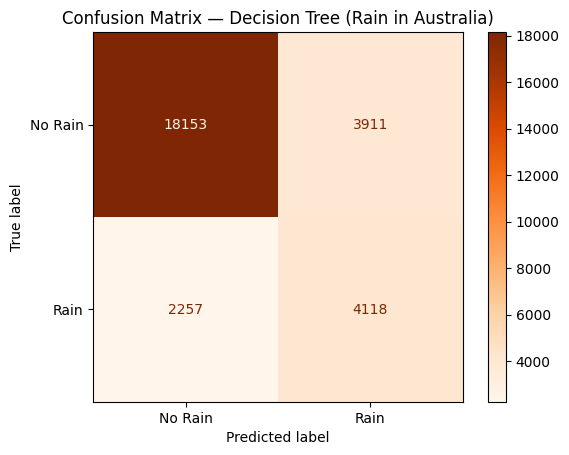

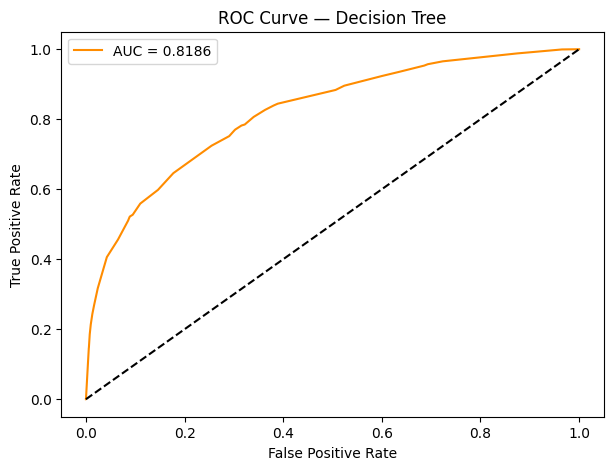

In [17]:
y_pred  = dt_best.predict(X_test)
y_proba = dt_best.predict_proba(X_test)[:, 1]

# ── Classification Report ─────────────────────────────────────────────────────
print(classification_report(y_test, y_pred, target_names=['No Rain', 'Rain']))

# ── ROC-AUC ───────────────────────────────────────────────────────────────────
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.4f}")

# ── Overfitting check ─────────────────────────────────────────────────────────
train_auc_tuned = roc_auc_score(y_train_bal, dt_best.predict_proba(X_train_bal)[:, 1])
print(f"Train AUC (tuned): {train_auc_tuned:.4f}")
print(f"Test  AUC (tuned): {auc:.4f}")
print(f"Overfit gap       : {train_auc_tuned - auc:.4f}")

# ── Confusion Matrix ──────────────────────────────────────────────────────────
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['No Rain', 'Rain'],
    cmap='Oranges'
)
plt.title("Confusion Matrix — Decision Tree (Rain in Australia)")
plt.show()

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Decision Tree")
plt.legend()
plt.show()

## Step 9 — Cross-validation score

In [18]:
cv_scores = cross_val_score(
    dt_best, X_train_bal, y_train_bal,
    cv=5, scoring='roc_auc', n_jobs=-1
)
print(f"CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV ROC-AUC: 0.8744 ± 0.0384


## Step 10 — Feature importance

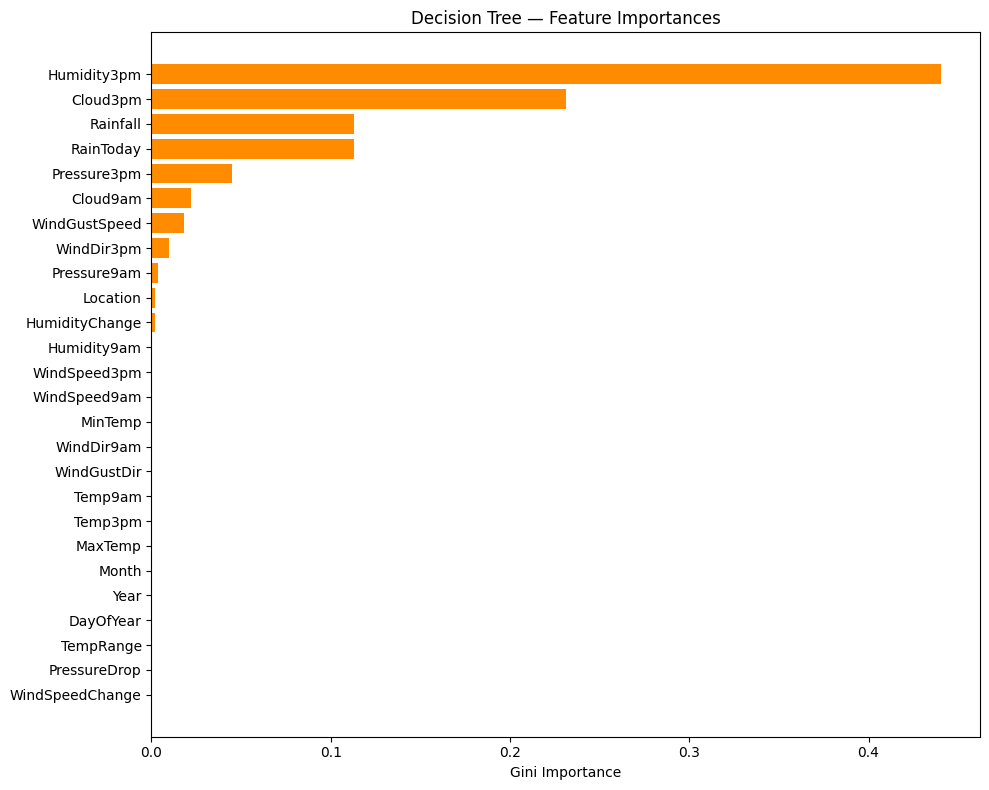

        Feature  Importance
    Humidity3pm    0.440182
       Cloud3pm    0.231403
       Rainfall    0.113089
      RainToday    0.112922
    Pressure3pm    0.045163
       Cloud9am    0.021835
  WindGustSpeed    0.018116
     WindDir3pm    0.009624
    Pressure9am    0.003567
       Location    0.002151
 HumidityChange    0.001949
    Humidity9am    0.000000
   WindSpeed3pm    0.000000
   WindSpeed9am    0.000000
        MinTemp    0.000000
     WindDir9am    0.000000
    WindGustDir    0.000000
        Temp9am    0.000000
        Temp3pm    0.000000
        MaxTemp    0.000000
          Month    0.000000
           Year    0.000000
      DayOfYear    0.000000
      TempRange    0.000000
   PressureDrop    0.000000
WindSpeedChange    0.000000


In [19]:
feature_names = X.columns.tolist()
importances   = dt_best.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='darkorange')
plt.xlabel("Gini Importance")
plt.title("Decision Tree — Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

## Step 11 — Visualise the tree (top 4 levels)

One of the biggest advantages of Decision Trees over all other models: you can **read the actual decision rules**. We plot only the top 4 levels for readability — the full tree can be hundreds of levels deep.

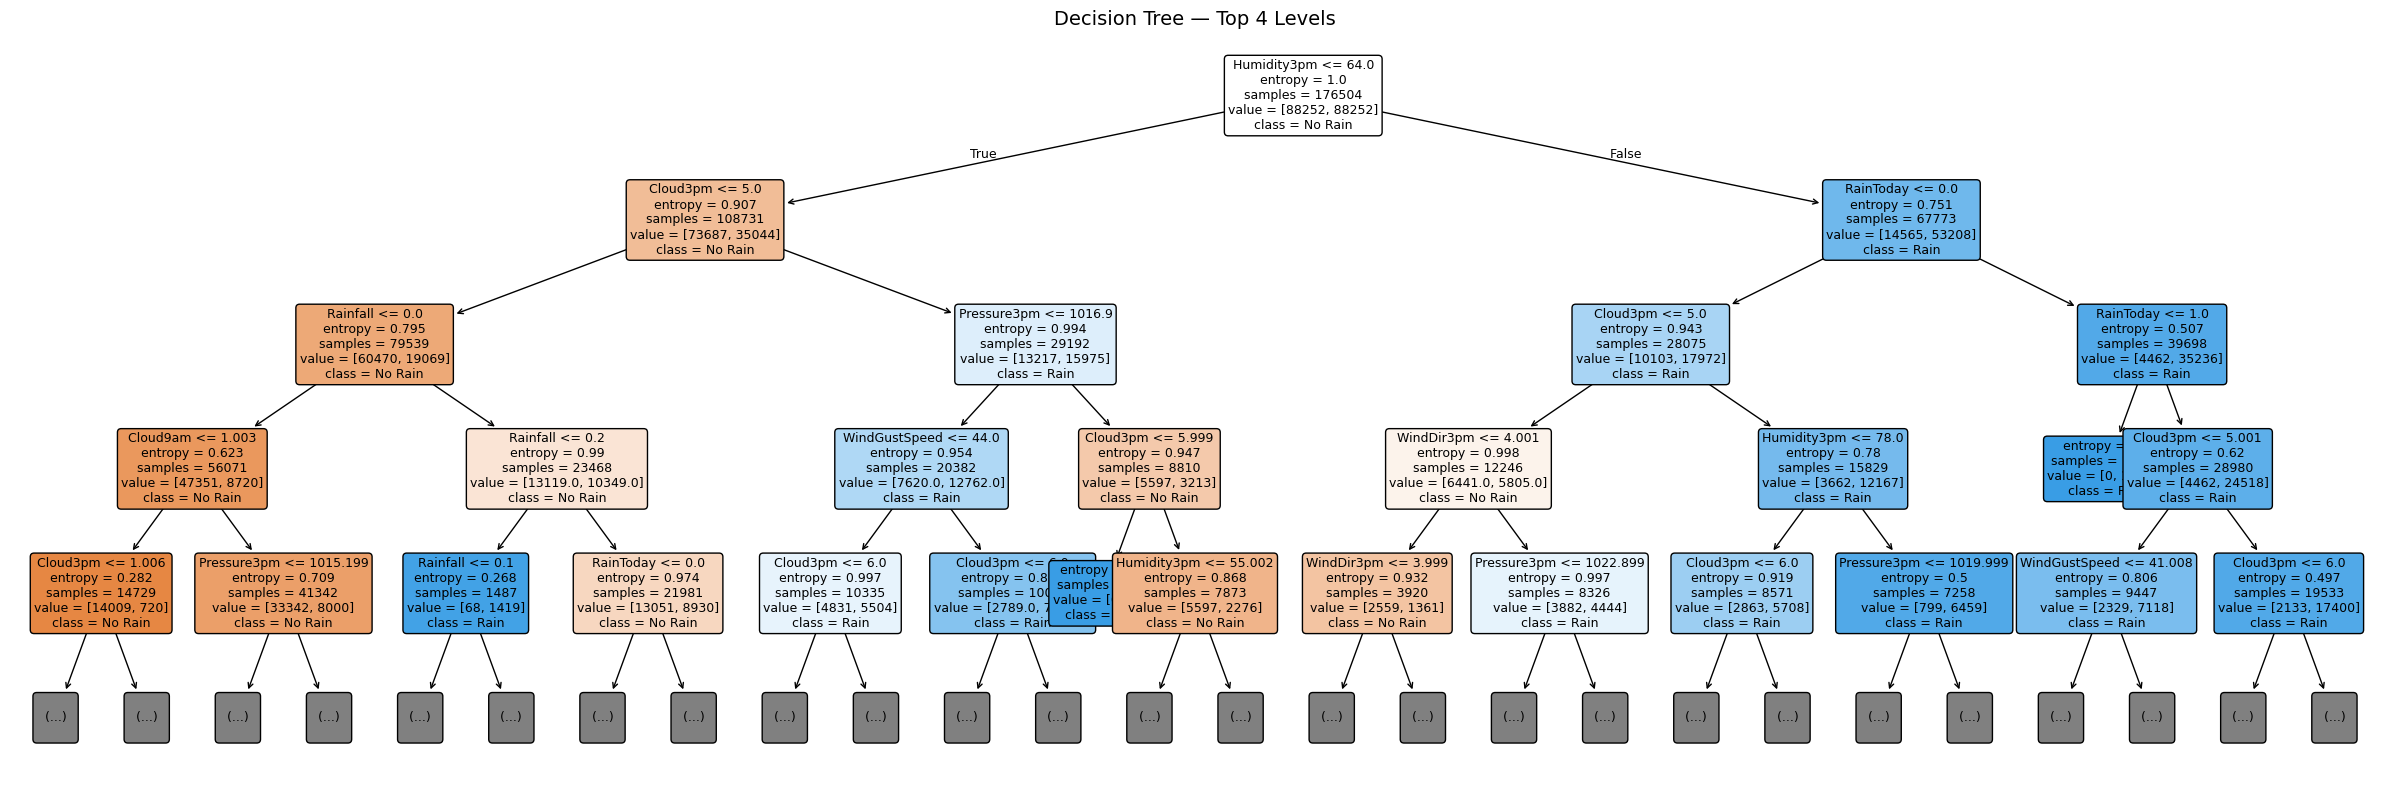

|--- Humidity3pm <= 64.00
|   |--- Cloud3pm <= 5.00
|   |   |--- Rainfall <= 0.00
|   |   |   |--- Cloud9am <= 1.00
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Cloud9am >  1.00
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- Rainfall >  0.00
|   |   |   |--- Rainfall <= 0.20
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Rainfall >  0.20
|   |   |   |   |--- truncated branch of depth 3
|   |--- Cloud3pm >  5.00
|   |   |--- Pressure3pm <= 1016.90
|   |   |   |--- WindGustSpeed <= 44.00
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- WindGustSpeed >  44.00
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- Pressure3pm >  1016.90
|   |   |   |--- Cloud3pm <= 6.00
|   |   |   |   |--- class: 1
|   |   |   |--- Cloud3pm >  6.00
|   |   |   |   |--- truncated branch of depth 3
|--- Humidity3pm >  64.00
|   |--- RainToday <= 0.00
|   |   |--- Cloud3pm <= 5.00
|   |   |   |--- WindDir3pm <= 4.00
|   |   |   | 

In [20]:
plt.figure(figsize=(24, 8))
plot_tree(
    dt_best,
    max_depth=4,                        # show top 4 levels only
    feature_names=feature_names,
    class_names=['No Rain', 'Rain'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree — Top 4 Levels", fontsize=14)
plt.tight_layout()
plt.show()

# Text version of the top 3 levels
print(export_text(dt_best, feature_names=feature_names, max_depth=3))

---
## Notes on Decision Tree vs other models

| Aspect                    | Decision Tree                 | Random Forest | SVM (RBF)   | Logistic Regression |
| ------------------------- | ----------------------------- | ------------- | ----------- | ------------------- |
| **Scaling required**      | ❌ No                          | ❌ No          | ✅ Yes       | ✅ Yes               |
| **Training speed**        | 🚀 Very fast                  | 🟡 Moderate   | 🐢 Slow     | 🚀 Fast             |
| **Tuning speed**          | 🚀 Very fast (Halving Search) | 🟡 Moderate   | 🐢 Slow     | 🚀 Fast             |
| **Interpretability**      | ✅ Highest (tree structure)    | 🟡 Medium     | ❌ Low       | ✅ High              |
| **Handles non-linearity** | ✅ Yes                         | ✅ Yes         | ✅ Yes       | ❌ No                |
| **Overfitting risk**      | 🟡 Controlled (after tuning)  | 🟢 Low        | 🟡 Moderate | 🟢 Low              |
| **AUC (this dataset)**    | **0.8186 (Test)**             | ~0.87–0.91    | ~0.85–0.87  | ~0.85–0.88          |


**Key takeaways:**
- The Decision Tree model achieved a ROC-AUC of 0.8186 on test data and 0.8801 on training data, with a small gap of 0.0615. This shows that the model performs well and does not overfit much.

- Compared to other models, the Decision Tree is the easiest to understand. We can clearly see how it makes decisions using features like humidity, cloud, and rainfall.

- Decision Trees can easily overfit, but in this case, tuning parameters such as maximum depth and minimum samples helped control that problem.

- Random Forest usually gives better performance because it combines many trees, which makes the model more stable and accurate.

- Logistic Regression is simple and stable, but it cannot handle complex patterns in the data.

- SVM can capture complex relationships, but it takes more time to train and is difficult to interpret.

- So, the Decision Tree is a good choice when we need a model that is fast and easy to explain, while Random Forest is better when we want higher accuracy.